In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
TRAIN_DIR = '/content/drive/MyDrive/INTERNSHIP/PlantVillage/train'
VAL_DIR   = '/content/drive/MyDrive/INTERNSHIP/PlantVillage/val'

In [5]:
#define transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
# load dataset
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR, transform=val_transforms)

class_names = train_dataset.classes
print("Number of classes:", len(class_names))

Number of classes: 38


In [7]:
# handle class imbalance
targets = train_dataset.targets
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [8]:
# create databloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [9]:
# loss function
criterion = nn.CrossEntropyLoss()

In [10]:
# training and validation function
def train_and_validate(model, train_loader, val_loader,
                       optimizer, criterion, device,
                       epochs=10, save_best=False):

    train_losses = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):

        # Training
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):

                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc  = correct / total

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {epoch_train_loss:.4f}")
        print(f"Val Loss: {epoch_val_loss:.4f}")
        print(f"Val Accuracy: {epoch_val_acc:.4f}\n")

        if save_best and epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

    if save_best:
        torch.save(best_model_wts,
                   "/content/drive/MyDrive/INTERNSHIP/best_cnn_model.pth")
        print("Best CNN model saved successfully!")

    return train_losses, val_losses, val_accuracies

In [11]:
# MLP
class MLP(nn.Module):
    def __init__(self, num_classes):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3*224*224, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [12]:
mlp_model = MLP(len(class_names)).to(device)
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=0.001)

mlp_train_losses, mlp_val_losses, mlp_val_accuracies = train_and_validate(
    mlp_model, train_loader, val_loader,
    optimizer_mlp, criterion, device,
    epochs=6, save_best=False
)

Validation: 100%|██████████| 340/340 [37:49<00:00,  6.67s/it]



Epoch [1/6]
Train Loss: 5.2767
Val Loss: 16.2058
Val Accuracy: 0.2910



Validation: 100%|██████████| 340/340 [00:57<00:00,  5.88it/s]



Epoch [2/6]
Train Loss: 4.2019
Val Loss: 51.1581
Val Accuracy: 0.2485



Validation: 100%|██████████| 340/340 [01:00<00:00,  5.66it/s]


...


Epoch [4/6]
Train Loss: 4.3882
Val Loss: 28.1665
Val Accuracy: 0.2688



Validation: 100%|██████████| 340/340 [00:59<00:00,  5.70it/s]



Epoch [5/6]
Train Loss: 3.9415
Val Loss: 31.7696
Val Accuracy: 0.2925



Validation: 100%|██████████| 340/340 [00:59<00:00,  5.75it/s]


Epoch [6/6]
Train Loss: 4.1974
Val Loss: 28.8859
Val Accuracy: 0.3236



In [13]:
#CNN
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64*56*56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [14]:
cnn_model = CNN(len(class_names)).to(device)
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_train_losses, cnn_val_losses, cnn_val_accuracies = train_and_validate(
    cnn_model, train_loader, val_loader,
    optimizer_cnn, criterion, device,
    epochs=8, save_best=True
)

Validation: 100%|██████████| 340/340 [01:01<00:00,  5.56it/s]



Epoch [1/8]
Train Loss: 1.3534
Val Loss: 0.6888
Val Accuracy: 0.7855



Validation: 100%|██████████| 340/340 [01:00<00:00,  5.59it/s]



Epoch [2/8]
Train Loss: 0.4990
Val Loss: 0.4529
Val Accuracy: 0.8538



Validation: 100%|██████████| 340/340 [01:00<00:00,  5.61it/s]


...


Epoch [6/8]
Train Loss: 0.2016
Val Loss: 0.2944
Val Accuracy: 0.9135



Validation: 100%|██████████| 340/340 [01:01<00:00,  5.57it/s]



Epoch [7/8]
Train Loss: 0.1784
Val Loss: 0.3249
Val Accuracy: 0.9090



Validation: 100%|██████████| 340/340 [01:01<00:00,  5.49it/s]



Epoch [8/8]
Train Loss: 0.1696
Val Loss: 0.3367
Val Accuracy: 0.9080

Best CNN model saved successfully!


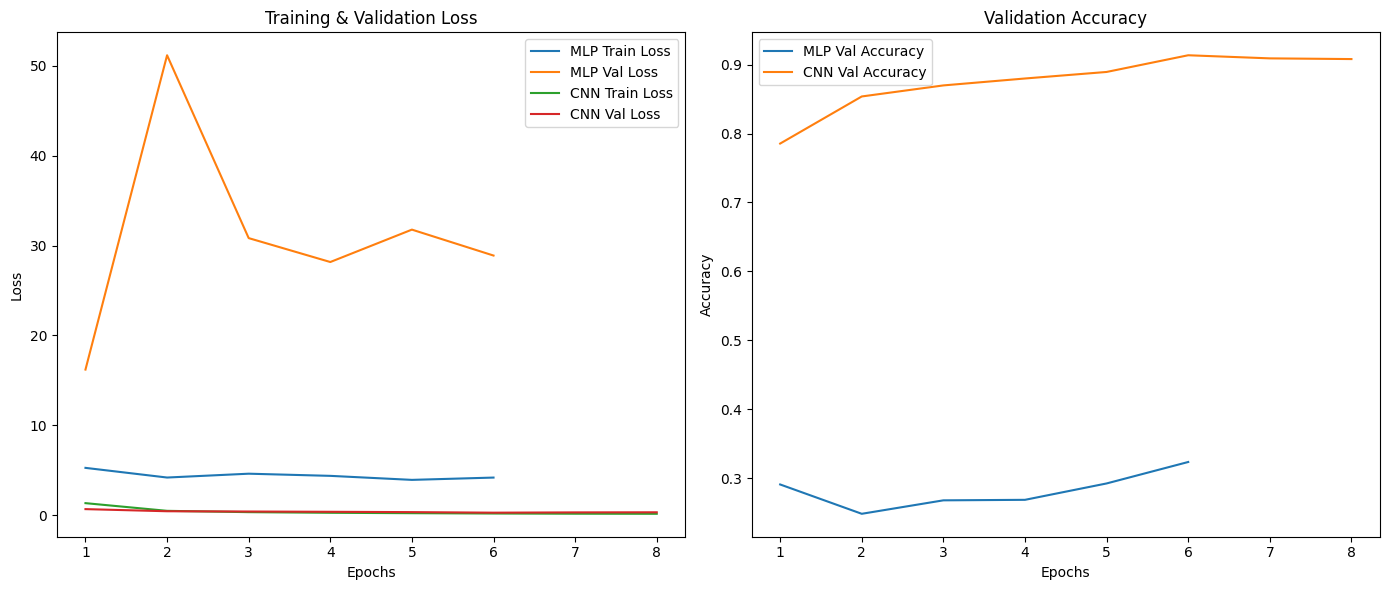

In [15]:
# comparison graphs
epochs_mlp = range(1, 7)
epochs_cnn = range(1, 9)

plt.figure(figsize=(14,6))

# loss curve
plt.subplot(1,2,1)
plt.plot(epochs_mlp, mlp_train_losses, label="MLP Train Loss")
plt.plot(epochs_mlp, mlp_val_losses, label="MLP Val Loss")
plt.plot(epochs_cnn, cnn_train_losses, label="CNN Train Loss")
plt.plot(epochs_cnn, cnn_val_losses, label="CNN Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

# accuracy curve
plt.subplot(1,2,2)
plt.plot(epochs_mlp, mlp_val_accuracies, label="MLP Val Accuracy")
plt.plot(epochs_cnn, cnn_val_accuracies, label="CNN Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# comparison table
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

comparison_df = pd.DataFrame({
    "Model": ["MLP (6 Epochs)", "CNN (8 Epochs - Best)"],
    "Final Train Loss": [
        mlp_train_losses[-1],
        cnn_train_losses[-1]
    ],
    "Best Val Loss": [
        min(mlp_val_losses),
        min(cnn_val_losses)
    ],
    "Best Val Accuracy": [
        max(mlp_val_accuracies),
        max(cnn_val_accuracies)
    ],
    "Total Parameters": [
        count_parameters(mlp_model),
        count_parameters(cnn_model)
    ]
})

comparison_df

,Model,Final Train Loss,Best Val Loss,Best Val Accuracy,Total Parameters
0,MLP (6 Epochs),4.197366,16.205796,0.323635,77090342
1,CNN (8 Epochs - Best),0.169597,0.294364,0.913544,51409638


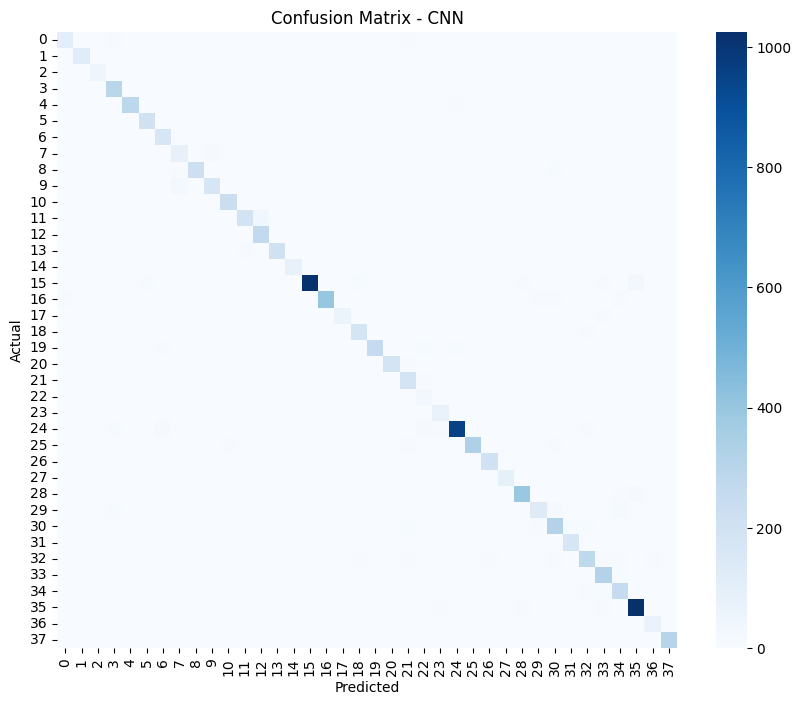

In [17]:
# confusion matrix
best_model = CNN(len(class_names)).to(device)
best_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/INTERNSHIP/best_cnn_model.pth"))
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# load the best CNN model
best_cnn_model = CNN(len(class_names)).to(device)
best_cnn_model.load_state_dict(
    torch.load("/content/drive/MyDrive/INTERNSHIP/best_cnn_model.pth"))
best_cnn_model.eval()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=38, bias=True)
)

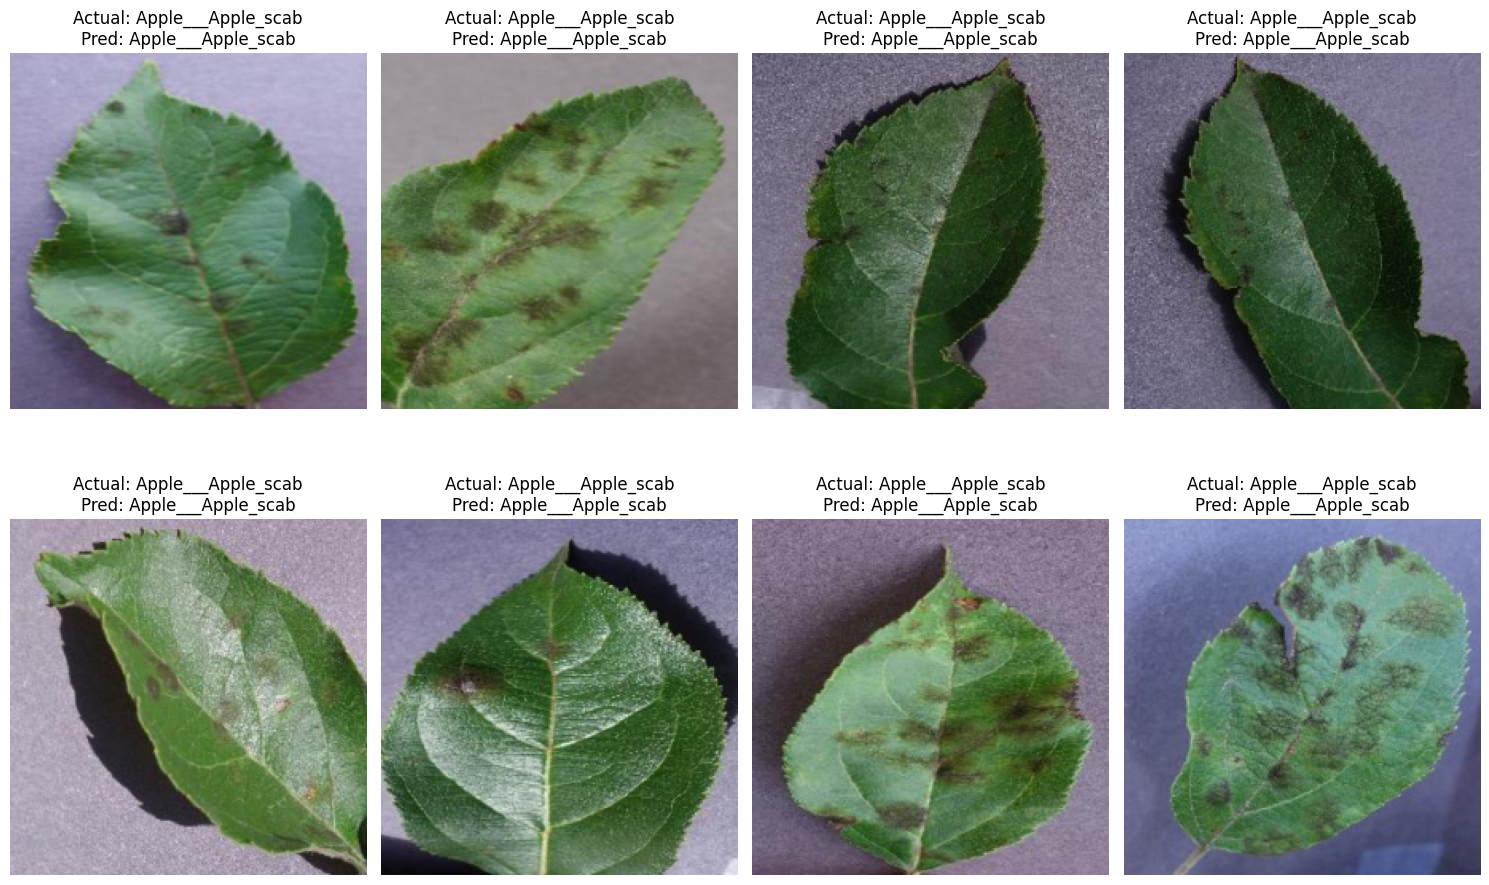

In [19]:
# comapare the actual and predicted values
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = best_cnn_model(images)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(15,10))

for i in range(8):
    plt.subplot(2,4,i+1)

    img = images[i].cpu().permute(1,2,0).numpy()
    img = (img * np.array([0.229,0.224,0.225])) + np.array([0.485,0.456,0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f"Actual: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()